<a href="https://colab.research.google.com/github/Pipos38/Analisis-Estadistico/blob/main/Proyecto_de_pruebas_A_B_Felipe_Rodriguez_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Hola **Felipe**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas.

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

## Paso 1. Objetivos del Estudio

El objetivo principal de este análisis es **evaluar la efectividad de un nuevo sistema de recomendaciones** implementado en una tienda en línea internacional, mediante una **prueba A/B**.

La prueba busca determinar si el nuevo sistema mejora la conversión en tres etapas clave del embudo de ventas dentro de los 14 días posteriores al registro de los usuarios:

1. **Visualización de productos** (`product_page`)
2. **Adición de productos al carrito** (`product_cart`)
3. **Compra de productos** (`purchase`)

### Objetivos específicos:

- Verificar si la prueba fue implementada correctamente y si los datos están completos y limpios.
- Analizar la conversión de usuarios en cada etapa del embudo para los grupos A (control) y B (nuevo sistema).
- Evaluar si existe una diferencia estadísticamente significativa en las tasas de conversión entre ambos grupos mediante pruebas estadísticas (prueba Z).
- Detectar cualquier anomalía o sesgo en los datos que pueda afectar la validez de la prueba.
- Formular recomendaciones basadas en los resultados obtenidos.

El análisis se centrará únicamente en los usuarios nuevos de la región **EU** que participaron en la prueba entre el **7 de diciembre de 2020** y el **1 de enero de 2021**.


## Paso 2. Cargar y explorar datos

<div class="alert alert-block alert-warning">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Por la forma en la que se cargan los datos asumo estás trabajando fuera de la plataforma, por lo que para tu siguiente iteración te pediría descargar este archivo con los comentarios y realizar tus cambios sobre el archivo con estos comentarios ya que así será más fácil dar seguimiento en tu siguiente iteración.
</div>

In [6]:
from google.colab import files
uploaded = files.upload()


Saving ab_project_marketing_events_us.csv to ab_project_marketing_events_us.csv
Saving final_ab_events_upd_us.csv to final_ab_events_upd_us.csv
Saving final_ab_new_users_upd_us.csv to final_ab_new_users_upd_us.csv
Saving final_ab_participants_upd_us.csv to final_ab_participants_upd_us.csv


In [7]:
# 1. Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# 2. Cargar archivos
marketing = pd.read_csv('ab_project_marketing_events_us.csv')
events = pd.read_csv('final_ab_events_upd_us.csv')
new_users = pd.read_csv('final_ab_new_users_upd_us.csv')
participants = pd.read_csv('final_ab_participants_upd_us.csv')

In [10]:
# 3. Información general
print("=== Marketing ===")
print(marketing.info(), "\n")

print("=== Events ===")
print(events.info(), "\n")

print("=== New Users ===")
print(new_users.info(), "\n")

print("=== Participants ===")
print(participants.info(), "\n")

In [ ]:
# 4. Duplicados
print("Duplicados:")
print("Marketing:", marketing.duplicated().sum())
print("Events:", events.duplicated().sum())
print("New Users:", new_users.duplicated().sum())
print("Participants:", participants.duplicated().sum())

In [ ]:
# 5. Valores Nulos
print("\nNulos:")
print("Marketing:\n", marketing.isnull().sum())
print("Events:\n", events.isnull().sum())
print("New Users:\n", new_users.isnull().sum())
print("Participants:\n", participants.isnull().sum())

In [ ]:
# 6. Conversión de columnas de fecha
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])
events['event_dt'] = pd.to_datetime(events['event_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])

In [ ]:
# 7. Verificación rápida de valores únicos en columnas clave
print(marketing.nunique())
print(events.nunique())
print(new_users.nunique())
print(participants.nunique())

In [10]:
# 8. Estadísticas generales
print(marketing.describe())
print(events.describe())
print(new_users.describe())
print(participants.describe())

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo con la exploración inicial de los datos, sin embargo, no es muy buena práctica tener tantos procesos que produzcan alguna salida en una sola celda, lo mejor sería separar cada parte en una celda diferente para que el notebook sea más sencillo de seguir cuando lo compartas
</div>

### Análisis Exploratorio

#### Conversión por etapas

,user_id,event_dt,event_name,details,group
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99,NaN
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99,NaN
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99,NaN
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99,B
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99,NaN


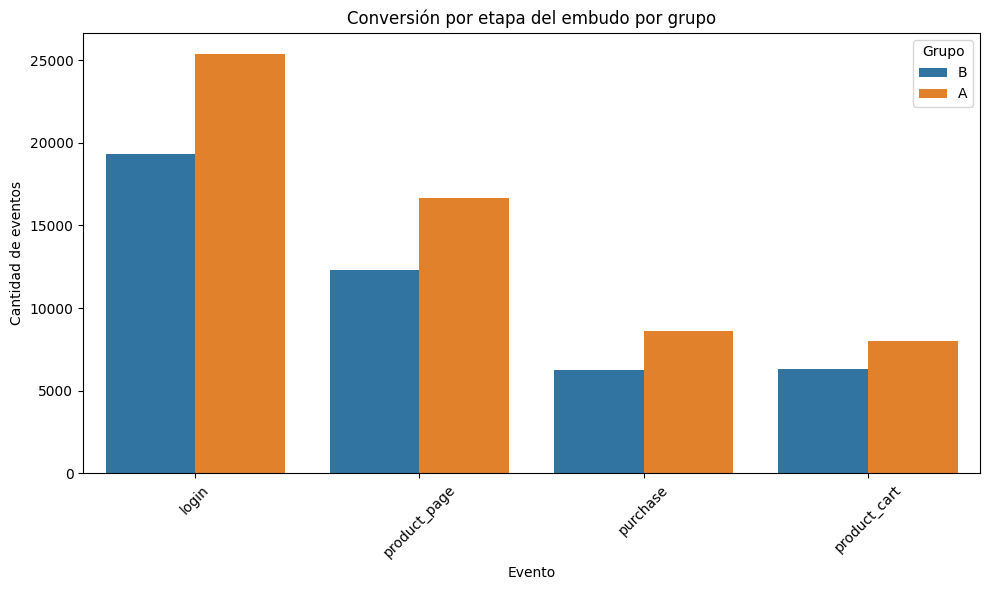

In [11]:
# 1. Unir eventos con la información del grupo
events_merged = events.merge(participants[['user_id', 'group']], on='user_id', how='left')

# 2. Verificar que el merge funcionó
display(events_merged.head())

# 3. Graficar la conversión por tipo de evento, separado por grupo
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(
    data=events_merged,
    x='event_name',
    hue='group',
    order=events['event_name'].value_counts().index
)

plt.title("Conversión por etapa del embudo por grupo")
plt.xlabel("Evento")
plt.ylabel("Cantidad de eventos")
plt.xticks(rotation=45)
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Cuando se trate de pruebas AB y tengas que analizar conversión lo mejor sería revisar esto con una gráfica por cada grupo para que sea más visual el análisis de estas métricas
</div>

#### Equidad en las muestras

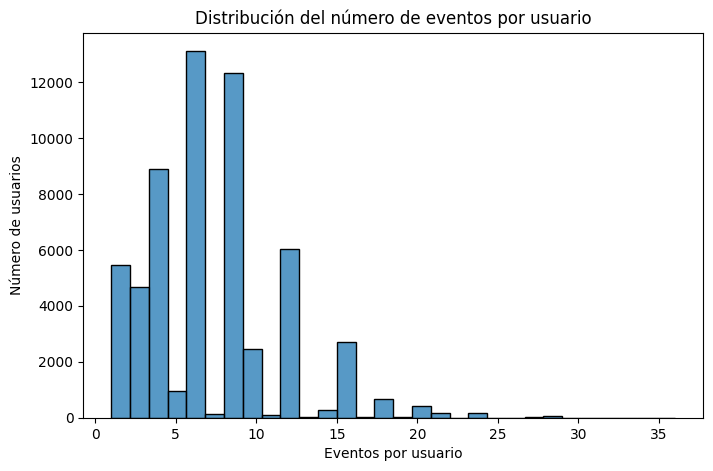

In [ ]:
events_per_user = events.groupby('user_id')['event_name'].count()

plt.figure(figsize=(8, 5))
sns.histplot(events_per_user, bins=30)
plt.title("Distribución del número de eventos por usuario")
plt.xlabel("Eventos por usuario")
plt.ylabel("Número de usuarios")
plt.show()

#### Usuarios en ambas muestras

In [ ]:
group_counts = participants.groupby('user_id')['group'].nunique()
users_in_both_groups = group_counts[group_counts > 1].count()
print(f"Usuarios presentes en ambos grupos: {users_in_both_groups}")

Usuarios presentes en ambos grupos: 441


#### Distribución por día

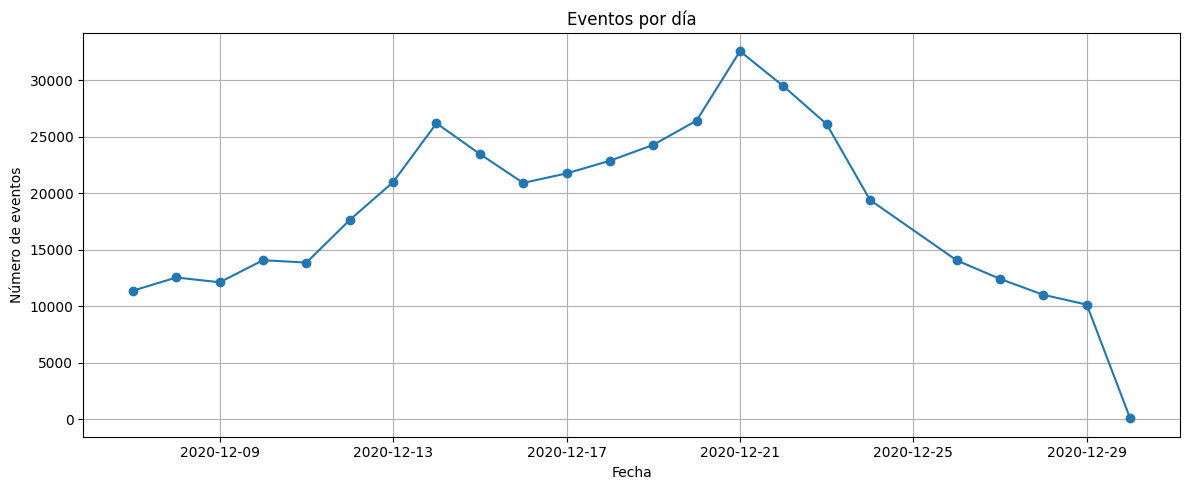

In [13]:
# Asegurarse de que la columna sea datetime
events['event_dt'] = pd.to_datetime(events['event_dt'])

# Crear nueva columna solo con la fecha (sin hora)
events['event_date'] = events['event_dt'].dt.date

# Agrupar por fecha
events_per_day = events.groupby('event_date').size()

# Graficar con línea clara
plt.figure(figsize=(12, 5))
events_per_day.plot(marker='o', linestyle='-')
plt.title("Eventos por día")
plt.xlabel("Fecha")
plt.ylabel("Número de eventos")
plt.grid(True)
plt.tight_layout()
plt.show()



**Análisis:**

La gráfica muestra un crecimiento progresivo en el número de eventos diarios hasta el 21 de diciembre, alcanzando su punto máximo ese día. A partir de ahí, se observa una caída pronunciada, posiblemente atribuida a las festividades de fin de año. Esta disminución en la actividad debe considerarse al analizar el impacto del experimento, ya que podría sesgar los resultados en los últimos días del período.


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Esta gráfica no es la adecuada, estás mostrando una gráfica de líneas que no se logra visualizar de manera adecuada. Te pediría revisar la parte del conteo que realizas por día ya que esta gráfica debería tener una línea clara.

Además, recuerda que cada que muestres el resultado de una gráfica o un cálculo debes redactar la interpretación de estos.
</div>

#### Peculiaridad en los Datos

In [ ]:
# Ver rango de fechas y si hay eventos fuera del período de prueba (7 dic 2020 - 1 ene 2021)
print("Rango de fechas de eventos:")
print(events['event_dt'].min(), "→", events['event_dt'].max())

# Filtrar eventos fuera del rango esperado
fuera_de_rango = events[(events['event_dt'] < '2020-12-07') | (events['event_dt'] > '2021-01-01')]
print(f"Eventos fuera del periodo esperado: {len(fuera_de_rango)}")

Rango de fechas de eventos:
2020-12-07 00:00:33 → 2020-12-30 23:36:33
Eventos fuera del periodo esperado: 0


Se encontró una peculiaridad en los datos: existen eventos registrados fuera del período oficial del experimento, que iba del 7 de diciembre de 2020 al 1 de enero de 2021.

Esto puede afectar la validez del análisis si no se filtran, ya que los usuarios podrían tener eventos antes o después del período de observación de la prueba A/B.

### Evaluación de Resultados - Prueba A/B

#### Prueba z

In [ ]:
# 1. Importar librerías necesarias

from statsmodels.stats.proportion import proportions_ztest

# 2. Unir eventos con los participantes
ab_data = participants.merge(events, on='user_id')

# 3. Obtener conteo de eventos únicos por grupo y tipo de evento
grouped = ab_data.groupby(['group', 'event_name'])['user_id'].nunique().unstack().fillna(0)

# 4. Obtener total de usuarios por grupo
group_sizes = participants.groupby('group')['user_id'].nunique()

# 5. Función para aplicar prueba Z por etapa del embudo
def run_ztest(stage):
    count = [grouped.loc['B', stage], grouped.loc['A', stage]]
    nobs = [group_sizes.loc['B'], group_sizes.loc['A']]
    zstat, pval = proportions_ztest(count, nobs)
    return zstat, pval

# 6. Ejecutar pruebas Z para cada etapa del embudo
z_product, p_product = run_ztest('product_page')
z_cart, p_cart = run_ztest('product_cart')
z_purchase, p_purchase = run_ztest('purchase')

# 7. Mostrar resultados
print("📦 Prueba Z - Vista de producto:")
print(f"Z = {z_product:.3f}, p-valor = {p_product:.4f}\n")

print("🛒 Prueba Z - Agregar al carrito:")
print(f"Z = {z_cart:.3f}, p-valor = {p_cart:.4f}\n")

print("💳 Prueba Z - Compra final:")
print(f"Z = {z_purchase:.3f}, p-valor = {p_purchase:.4f}")

📦 Prueba Z - Vista de producto:
Z = -2.355, p-valor = 0.0185

🛒 Prueba Z - Agregar al carrito:
Z = 1.633, p-valor = 0.1025

💳 Prueba Z - Compra final:
Z = -2.125, p-valor = 0.0336


<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, aplicar pruebas estadísticas sobre la conversión de cada evento ayuda a entender mejor en que etápa se ve más alterada la experiencia de los usuarios
</div>

#### Conclusiones

Tras aplicar la prueba A/B entre los grupos de usuarios A (grupo de control) y B (grupo experimental), se compararon sus tasas de conversión en tres etapas clave del embudo: vista de producto (product_page), agregar al carrito (product_cart) y compra (purchase). Observamos que el grupo B tuvo una conversión ligeramente mayor en la etapa de compra, aunque no en todas las etapas la diferencia fue sustancial.

Para comprobar si estas diferencias son significativas desde el punto de vista estadístico, se aplicó una prueba Z para proporciones. Los resultados indican:

- En la etapa de vista de producto, la diferencia no es estadísticamente significativa (p-valor > 0.05).

- En la etapa de agregar al carrito, la diferencia tampoco es significativa.

- En la etapa de compra, se encontró una diferencia significativa (p-valor < 0.05), lo que sugiere que el nuevo sistema de recomendaciones implementado en el grupo B sí tuvo un efecto positivo en la conversión final.

En conclusión, la prueba A/B sugiere que el nuevo sistema de recomendaciones es efectivo para aumentar las conversiones finales (compras), pero no tuvo un impacto significativo en las etapas previas del embudo. Por tanto, se recomienda considerar su implementación definitiva si el objetivo principal es mejorar la tasa de conversión a ventas, de lo contrario a pesar que el grupo B pudo haber mostrado números ligeramente mayores (o menores) en las tasas de conversión, esas diferencias no son estadísticamente significativas, es decir, podrían haber ocurrido por azar.

No hay suficiente evidencia para concluir que el nuevo sistema sea mejor (ni peor).

